## Goal: Learn how to read in data into dataframe and do analysis on it

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

### First make sure to download today's script into your own computer. 
Should be available at the following link: 

### Whenever you have a new file we need to determine the best way to open it and interpret what's inside. 
#### For ASCII files (ie. .txt, .csv, .tsv, .dat, .de1... etc) we can used a pandas dataframe

In [6]:
#An Example of a Dataframe from last session 
data = {
    "Name": ["Alice", "Bob", "Charlie", "David"],
    "Age": [25, 30, 35, 22],
    "City": ["New York", "London", "Paris", "Tokyo"],
    "Salary": [70000, 85000, 95000, 62000]
}

df = pd.DataFrame(data)
display(df)

,Name,Age,City,Salary
0,Alice,25,New York,70000
1,Bob,30,London,85000
2,Charlie,35,Paris,95000
3,David,22,Tokyo,62000


### Lets grab our file and make our own dataframe

In [ ]:
#First lets get the "path" of our file. Basically whats the address of where your file lives in your computer

#On MY PERSONAL windows the path is "C:\Users\jrich\Downloads\W1_boulder_20230823T16_SHADOZV06.dat"

#Method 1:
sondepath = Path(r"C:\Users\jrich\Downloads\W1_boulder_20230823T16_SHADOZV06.dat") #Changing our string path into a path object 

#Method 2:
current_path = "C:/Users/jrich/Downloads/W1_boulder_20230823T16_SHADOZV06.dat"
sondepath = Path(current_path)

type(sondepath)

pathlib._local.WindowsPath

In [ ]:
#Path is really cool

test1 = sondepath.with_suffix(".csv") #Change the extension
test2 = sondepath.name #grab only the name of the file
test3 = sondepath.parent #What is the folder location of this file in your computer
test4 = str(test3) + r"\randomnewfile.txt" #Maybe youll use it to make a file name for later
test5 = Path(test4) #Make that name into a Path
test6 = test5.exists() #See if the file exist in your computer at the address that was given

print("sondepath:", sondepath,'\n')
print("Test 1:", test1,'\n')
print("Test 2:", test2,'\n')
print("Test 3:", test3,'\n')
print("Test 4:", test4,'\n')
print("Test 5:", test5,'\n')
print("Test 6:", test6)

sondepath: C:\Users\jrich\Downloads\W1_boulder_20230823T16_SHADOZV06.dat 

Test 1: C:\Users\jrich\Downloads\W1_boulder_20230823T16_SHADOZV06.csv 

Test 2: W1_boulder_20230823T16_SHADOZV06.dat 

Test 3: C:\Users\jrich\Downloads 

Test 4: C:\Users\jrich\Downloads\randomnewfile.txt 

Test 5: C:\Users\jrich\Downloads\randomnewfile.txt 

Test 6: False


In [8]:
header = ['Time[sec]','Press[hpa]','Alt[km]','Temp[deg C]',
                              'RH[%]','O3P[mPa]','O3Mr[ppmv]','O3_DU[DU]','Wind_Dir[deg]','Wind Speed[m/s]','TPump[deg C]','O3CellI[uA]',
                              'GPS_Lat[deg]','GPS_Lon[deg]','GPS_Alt[km]'] #Titles of the dataframe
skip = 36 #how many rows i'd like to skip
delimiter = '\s+' #How is the data seperated? For example in a .csv its a comma seperated file so the delimeter should be ','
path = sondepath #Path of the file I want to make a dataframe

sondeDF = pd.read_csv(path, skiprows = skip, names = header, sep = delimiter)
sondeDF

,Time[sec],Press[hpa],Alt[km],Temp[deg C],RH[%],O3P[mPa],O3Mr[ppmv],O3_DU[DU],Wind_Dir[deg],Wind Speed[m/s],TPump[deg C],O3CellI[uA],GPS_Lat[deg],GPS_Lon[deg],GPS_Alt[km]
0,9000,832.72,1.743,27.40,29.4,4.3080,0.0517,9000,9000,9000,9000,9000,9000,9000,9000
1,9000,831.09,1.760,26.21,29.2,4.3119,0.0519,9000,9000,9000,9000,9000,9000,9000,9000
2,9000,830.58,1.766,26.07,29.1,4.3395,0.0522,9000,9000,9000,9000,9000,9000,9000,9000
3,9000,830.10,1.771,25.99,29.4,4.3434,0.0523,9000,9000,9000,9000,9000,9000,9000,9000
4,9000,829.63,1.776,25.93,29.4,4.3513,0.0524,9000,9000,9000,9000,9000,9000,9000,9000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11166,9000,827.41,1.799,27.75,31.1,5.4184,0.0655,9000,9000,9000,9000,9000,9000,9000,9000
11167,9000,827.65,1.797,27.77,30.9,5.4257,0.0656,9000,9000,9000,9000,9000,9000,9000,9000
11168,9000,827.98,1.793,27.71,30.4,5.3964,0.0652,9000,9000,9000,9000,9000,9000,9000,9000
11169,9000,829.18,1.781,27.82,29.7,5.3944,0.0651,9000,9000,9000,9000,9000,9000,9000,9000


### Quick Excerices
1) Print the highest height this sonde reaches
2) What is the flagger for abd data in the file. With that info edit the cell to remove all rows that have bad data.
3) Print out the index of the highest height and trim the dataframe to only include rows before that index.
4) Challenge for those who complete 1-3 quickly: Plot a temperature versus altitude plot 


In [22]:
# Section 1:

#Method 1
max_height = max(sondeDF['Alt[km]'])
print(max_height, "km\n")

#Method 2
max_height = sondeDF['Alt[km]'].max()
print(f"Maximum altitude reached: {max_height:.2f} km") # the .2f allows the number to be formatted so it only has 2 sig figs

29.247 km

Maximum altitude reached: 29.25 km


In [ ]:
# Section 2:

#Make them all nan then drop them
sondeDF2 = sondeDF.replace(9000, np.nan)
sondeDF2 = sondeDF2.dropna().reset_index(drop = True)

#Apply a mask
mask = (sondeDF != 9000).all(axis=1)
sondeDF3 = sondeDF[mask].reset_index(drop = True) #You can make mas first then put it in
sondeDF4 = sondeDF[~(sondeDF == 9000).any(axis=1)].reset_index(drop = True) #or just put it straight in

#We could apply a mask based on a specific list of columns
specificMask = (sondeDF['Temp[deg C]'] != 9000) & (sondeDF['RH[%]'] != 9000) & (sondeDF['O3Mr[ppmv]'] != 9000)
sondeDF5 = sondeDF[specificMask]


0        False
1        False
2        False
3        False
4        False
         ...  
11166    False
11167    False
11168    False
11169    False
11170    False
Length: 11171, dtype: bool

In [ ]:
#Section 3:
maxalt_index = sondeDF['Alt[km]'].idxmax()
sondeDF6 = sondeDF.loc[:maxalt_index].reset_index(drop = True)

print(sondeDF.shape, sondeDF6.shape)


(11171, 15) (5164, 15)


In [29]:
sondeDFascent = sondeDF6

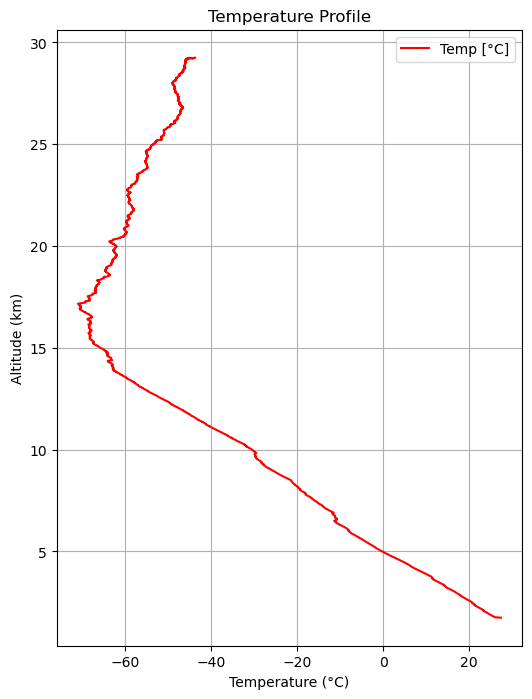

In [33]:
#Section 4:
fig, ax = plt.subplots(figsize=(6, 8))

ax.plot(sondeDFascent['Temp[deg C]'], sondeDFascent['Alt[km]'], label= "Temp [°C]", color = "red")

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Temperature Profile')
ax.grid()
ax.legend()

plt.show()

### Why is there a temperature inversion? Because the ozonesonde is climing through the ozone layer. Let try and plot both together

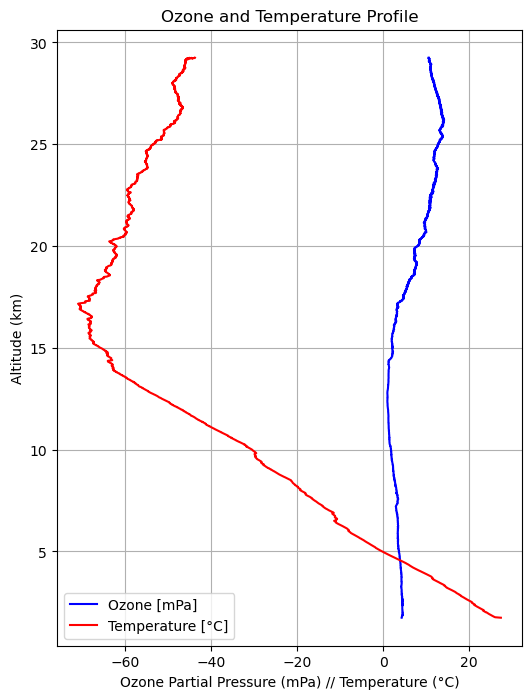

In [41]:
fig, ax = plt.subplots(figsize=(6, 8))

ax.plot(sondeDFascent['O3P[mPa]'], sondeDFascent['Alt[km]'], color='blue', label='Ozone [mPa]')
ax.plot(sondeDFascent['Temp[deg C]'], sondeDFascent['Alt[km]'], color='red', label='Temperature [°C]')
ax.set_xlabel('Ozone Partial Pressure (mPa) // Temperature (°C)')
ax.set_ylabel('Altitude (km)')
ax.grid(True)
ax.set_title('Ozone and Temperature Profile')
ax.legend()
plt.show()

### We can make this better...

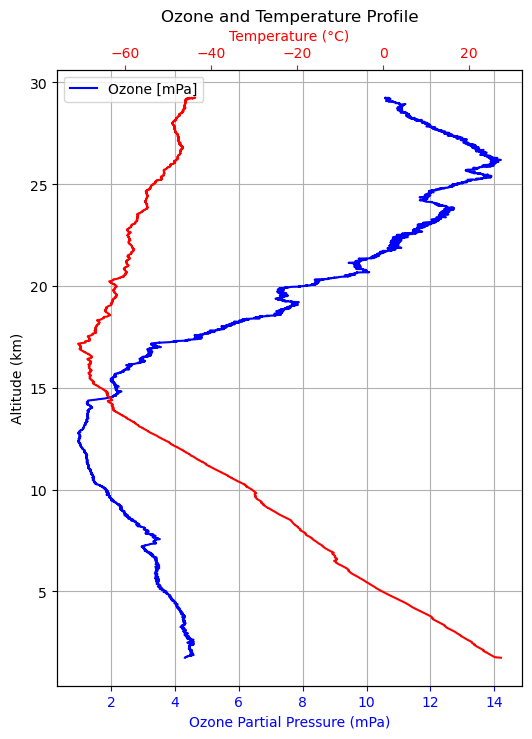

In [ ]:
fig, ax = plt.subplots(figsize=(6, 8))

ax.plot(sondeDFascent['O3P[mPa]'], sondeDFascent['Alt[km]'], color='blue', label='Ozone [mPa]')
ax.set_xlabel('Ozone Partial Pressure (mPa)', color='blue')
ax.set_ylabel('Altitude (km)')
ax.tick_params(axis='x', colors='blue')
ax.grid(True)

# COMBINING AXES BY USING THIS
ax2 = ax.twiny()

ax2.plot(sondeDFascent['Temp[deg C]'], sondeDFascent['Alt[km]'], color='red', label='Temperature [°C]')
ax2.set_xlabel('Temperature (°C)', color='red')
ax2.tick_params(axis='x', colors='red')

plt.title('Ozone and Temperature Profile')
plt.show()

## Improving your python workflow

In [ ]:
i = 0
while i != 1:
    check = input("Is this Windows (1) or Mac (2): ")
    try:
        addyval = int(check)
        if addyval == 1:
            addy = '/Users/jrich/iCloudDrive/Documents/Nasa Spring 2023 Proj/'
            i = 1
        elif addyval == 2:
            addy = '/Users/jushuwa/Documents/Nasa Spring 2023 Proj/'
            i = 1
        else:
            print("Input 1 or 2")
    except:
        print("Input 1 or 2")

#### How to get the path of many files under the same name : Use rglob or glob from Pathlib library

In [ ]:
#How to get the path of many files under the same name
poshomPATHS = [str(x) for x in Path(addy + 'HUBV Homogenization/PostHom_PreSkySonde_03142025/HUBC_FinalHomogenizedFiles_011326/Final FLT/').rglob("*_homFLT.DAT") if str(x)[-26:-22] != '2005'] 
print(len(poshomPATHS))

In [ ]:
#How to save your fat .csv into something smaller and quicker
#.parquet

temp = sondeDF.to_parquet(sondepath.with_suffix(".parquet")) #Check the size of that file later
newdf = pd.read_parquet(sondepath.with_suffix(".parquet"))
newdf

,Time[sec],Press[hpa],Alt[km],Temp[deg C],RH[%],O3P[mPa],O3Mr[ppmv],O3_DU[DU],Wind_Dir[deg],Wind Speed[m/s],TPump[deg C],O3CellI[uA],GPS_Lat[deg],GPS_Lon[deg],GPS_Alt[km]
0,9000,832.72,1.743,27.40,29.4,4.3080,0.0517,9000,9000,9000,9000,9000,9000,9000,9000
1,9000,831.09,1.760,26.21,29.2,4.3119,0.0519,9000,9000,9000,9000,9000,9000,9000,9000
2,9000,830.58,1.766,26.07,29.1,4.3395,0.0522,9000,9000,9000,9000,9000,9000,9000,9000
3,9000,830.10,1.771,25.99,29.4,4.3434,0.0523,9000,9000,9000,9000,9000,9000,9000,9000
4,9000,829.63,1.776,25.93,29.4,4.3513,0.0524,9000,9000,9000,9000,9000,9000,9000,9000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11166,9000,827.41,1.799,27.75,31.1,5.4184,0.0655,9000,9000,9000,9000,9000,9000,9000,9000
11167,9000,827.65,1.797,27.77,30.9,5.4257,0.0656,9000,9000,9000,9000,9000,9000,9000,9000
11168,9000,827.98,1.793,27.71,30.4,5.3964,0.0652,9000,9000,9000,9000,9000,9000,9000,9000
11169,9000,829.18,1.781,27.82,29.7,5.3944,0.0651,9000,9000,9000,9000,9000,9000,9000,9000


In [ ]:
#How to make a checkpoint for you dataframe instead of rerunning everything 
#pickle
import pickle

#Writes the file
with open("testpickle.pkl", "wb") as file:
    loaded_data = pickle.dump(sondeDFascent, file)  

In [ ]:
sondeDFascent

In [ ]:
with open("testpickle.pkl", "rb") as file:
    sondeDFascent = pickle.load(file)  

sondeDFascent